# SentinelAI — المرحلة ٣ (الخطوة الأخيرة): اختيار أفضل نموذج وتحسينه

هذا آخر ملف في المرحلة ٣. نختار أفضل نموذج من بين الخوارزميات السبع، نحسّن إعداداته
(Hyperparameter Tuning)، ونحفظه كـ `models/best_model.joblib` — وهو النموذج الذي
سيستخدمه **الوكيل الذكي** لاحقاً كأداة من أدواته.

### أي نموذج هو "الأفضل"؟ (بالأرقام، وليس تخميناً)
من جدول مقارنة الملف `03_supervised.ipynb` (المرتّب حسب F1-score macro، لأنه المقياس
العادل مع بيانات غير متوازنة):

| النموذج | F1-macro |
|---|---|
| **Gradient Boosting (XGBoost)** | **0.9139** |
| Random Forest | 0.8802 |
| Logistic Regression | 0.7045 |
| CNN (من ملف لاحق) | 0.6474 |

**XGBoost هو الأعلى فعلياً** (0.914 مقابل 0.880 لـ Random Forest)، لذلك هو من سنحسّنه هنا،
وليس Random Forest.

In [1]:
import os
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import RandomizedSearchCV, KFold, train_test_split
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, f1_score, make_scorer,
    classification_report, confusion_matrix,
)
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid")

PROCESSED_DIR = os.path.join("..", "data", "processed")
MODELS_DIR = os.path.join("..", "models")
RANDOM_STATE = 42

**ماذا فعلنا ولماذا؟**
استوردنا `RandomizedSearchCV` للبحث عن أفضل إعدادات (بدل `GridSearchCV` الذي يجرّب كل
توليفة ممكنة — بطيء جداً على بيانات بهذا الحجم). استوردنا أيضاً `KFold` عادي (وليس
Stratified) — سنشرح السبب لاحقاً عند استخدامه.

In [2]:
X_train = np.load(os.path.join(PROCESSED_DIR, "X_train.npy"))
X_test = np.load(os.path.join(PROCESSED_DIR, "X_test.npy"))
y_train = np.load(os.path.join(PROCESSED_DIR, "y_train.npy"))
y_test = np.load(os.path.join(PROCESSED_DIR, "y_test.npy"))

with open(os.path.join(PROCESSED_DIR, "label_mapping.json"), encoding="utf-8") as f:
    label_mapping = {int(k): v for k, v in json.load(f).items()}

with open(os.path.join(PROCESSED_DIR, "class_weights.json"), encoding="utf-8") as f:
    class_weights = {int(k): v for k, v in json.load(f).items()}

classes_sorted = sorted(label_mapping.keys())
class_names_sorted = [label_mapping[c] for c in classes_sorted]

label_encoder = joblib.load(os.path.join(MODELS_DIR, "xgboost_label_encoder.joblib"))
y_train_encoded = label_encoder.transform(y_train)
sample_weight_train = np.array([class_weights[label] for label in y_train])

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

X_train: (908327, 77), X_test: (227082, 77)


**ماذا فعلنا ولماذا؟**
حمّلنا نفس بيانات المرحلة ٢، وأعدنا استخدام **نفس** `LabelEncoder` المحفوظ من ملف
`03_supervised.ipynb` (وليس واحداً جديداً) لضمان تطابق ترقيم الفئات (0..10) تماماً بين
النموذج القديم والنموذج المحسَّن الجديد.

In [3]:
baseline_model = joblib.load(os.path.join(MODELS_DIR, "gradient_boosting_xgboost.joblib"))

baseline_pred_encoded = baseline_model.predict(X_test)
baseline_pred = label_encoder.inverse_transform(baseline_pred_encoded)

baseline_acc = accuracy_score(y_test, baseline_pred)
baseline_p, baseline_r, baseline_f1, _ = precision_recall_fscore_support(
    y_test, baseline_pred, average="macro", zero_division=0
)

print("===== XGBoost قبل التحسين (Baseline) =====")
print(f"Accuracy: {baseline_acc:.4f} | Precision: {baseline_p:.4f} | "
      f"Recall: {baseline_r:.4f} | F1-macro: {baseline_f1:.4f}")

===== XGBoost قبل التحسين (Baseline) =====
Accuracy: 0.9998 | Precision: 0.8798 | Recall: 0.9797 | F1-macro: 0.9139


**ماذا فعلنا ولماذا؟**
أعدنا حساب مقاييس نموذج XGBoost الأصلي (غير المحسَّن) على نفس بيانات الاختبار، بنفس الطريقة
بالضبط، لنحصل على رقم "قبل" دقيق ومباشر للمقارنة، بدل الاعتماد فقط على الرقم المكتوب في
ملف سابق.

In [4]:
SEARCH_SAMPLE_SIZE = 100000

X_search, _, y_search_encoded, _ = train_test_split(
    X_train, y_train_encoded,
    train_size=SEARCH_SAMPLE_SIZE,
    stratify=y_train_encoded,
    random_state=RANDOM_STATE,
)

print(f"حجم عيّنة البحث عن أفضل الإعدادات: {X_search.shape[0]:,} من أصل {X_train.shape[0]:,}")

حجم عيّنة البحث عن أفضل الإعدادات: 100,000 من أصل 908,327


**ماذا فعلنا ولماذا؟ (لماذا عيّنة للبحث فقط؟)**
`RandomizedSearchCV` يدرّب النموذج عشرات المرات (توليفات إعدادات × عدد التقسيمات). تدريب
XGBoost عشرات المرات على 900 ألف صف كاملة سيأخذ وقتاً طويلاً جداً. لذلك نبحث عن أفضل
الإعدادات على عيّنة أصغر (100,000 صف) — سريعة بما يكفي للبحث — ثم في الخطوة الأخيرة نأخذ
أفضل إعدادات وُجدت وندرّب بها النموذج **النهائي على كامل بيانات التدريب** (كما فعلنا مع
النموذج الأصلي)، حتى لا نخسر أي بيانات في النموذج المُسلَّم فعلياً.

In [5]:
param_distributions = {
    "n_estimators": [100, 150, 200, 250, 300],
    "max_depth": [4, 5, 6, 7, 8],
    "learning_rate": [0.05, 0.1, 0.15, 0.2],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
}

f1_macro_scorer = make_scorer(f1_score, average="macro", zero_division=0)

# نستخدم KFold عادي (غير Stratified) بسبب وجود فئات نادرة جداً (بعضها أقل من 10 صفوف
# في كل بيانات التدريب) — StratifiedKFold يفشل إن كان عدد صفوف فئة أقل من عدد الطيّات.
cv_strategy = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

search = RandomizedSearchCV(
    estimator=XGBClassifier(random_state=RANDOM_STATE, n_jobs=1, eval_metric="mlogloss"),
    param_distributions=param_distributions,
    n_iter=15,
    scoring=f1_macro_scorer,
    cv=cv_strategy,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)

start = time.time()
search.fit(X_search, y_search_encoded)
search_time = time.time() - start

print(f"\nوقت البحث: {search_time:.1f} ثانية ({search_time/60:.1f} دقيقة)")
print(f"أفضل F1-macro أثناء البحث (على عيّنة البحث فقط): {search.best_score_:.4f}")
print("أفضل إعدادات:")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")

Fitting 3 folds for each of 15 candidates, totalling 45 fits



وقت البحث: 425.9 ثانية (7.1 دقيقة)
أفضل F1-macro أثناء البحث (على عيّنة البحث فقط): 0.8358
أفضل إعدادات:
  subsample: 0.9
  n_estimators: 200
  max_depth: 5
  learning_rate: 0.2
  colsample_bytree: 0.7


**ماذا فعلنا ولماذا؟**
جرّبنا **15 توليفة عشوائية** من 5 إعدادات مهمة في XGBoost (`n_estimators`, `max_depth`,
`learning_rate`, `subsample`, `colsample_bytree`)، كل توليفة تُقيَّم بطريقة Cross-Validation
بـ 3 طيّات، باستخدام F1-macro كمقياس تقييم (وليس Accuracy، لنفس سبب اختيار هذا المقياس
في الملفات السابقة).

**ملاحظة عن أوزان الفئات هنا:** لم نمرّر `sample_weight` أثناء هذا البحث تحديداً (لتفادي
تعقيد إضافي في كيفية توزيع الأوزان بين طيّات الـ Cross-Validation)، واعتمدنا بدلاً من ذلك
على أن F1-macro نفسه يعطي وزناً متساوياً لكل فئة عند التقييم، فيدفع البحث تلقائياً نحو
إعدادات تخدم كل الفئات لا الفئة الكبيرة فقط. أوزان الفئات (`sample_weight`) سنستخدمها
بشكل كامل في الخطوة التالية عند تدريب **النموذج النهائي** على كل البيانات.

In [6]:
start = time.time()
tuned_model = XGBClassifier(
    **search.best_params_,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    eval_metric="mlogloss",
)
tuned_model.fit(X_train, y_train_encoded, sample_weight=sample_weight_train)
tuned_train_time = time.time() - start

print(f"وقت تدريب النموذج النهائي المحسَّن على كامل البيانات: {tuned_train_time:.1f} ثانية")

وقت تدريب النموذج النهائي المحسَّن على كامل البيانات: 187.0 ثانية


**ماذا فعلنا ولماذا؟**
أخذنا أفضل إعدادات وجدها البحث، ودرّبنا بها نموذج XGBoost **جديد من الصفر** على **كامل**
بيانات التدريب (908,327 صف) مع `sample_weight` الكامل لمعالجة عدم التوازن — تماماً بنفس
أسلوب تدريب النموذج الأصلي في `03_supervised.ipynb`، لكن بإعدادات محسَّنة بدل الإعدادات
الافتراضية.

===== XGBoost بعد التحسين (Tuned) =====
Accuracy: 0.9999 | Precision: 0.9009 | Recall: 0.9747 | F1-macro: 0.9307

              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00    176012
    Attack_2       1.00      1.00      1.00      7026
    Attack_3       1.00      1.00      1.00      6763
    Attack_4       1.00      1.00      1.00     24856
    Attack_5       1.00      1.00      1.00     10410
    Attack_6       1.00      1.00      1.00      1520
    Attack_7       0.99      1.00      1.00       406
    Attack_8       1.00      1.00      1.00        60
    Attack_9       0.43      0.72      0.54        18
   Attack_10       0.82      1.00      0.90         9
   Attack_11       0.67      1.00      0.80         2

    accuracy                           1.00    227082
   macro avg       0.90      0.97      0.93    227082
weighted avg       1.00      1.00      1.00    227082



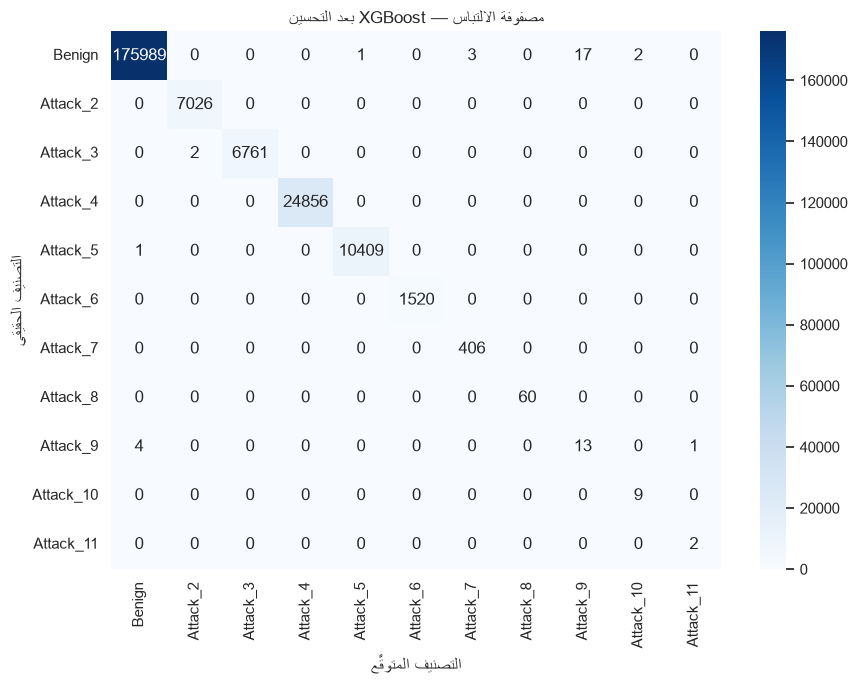

In [7]:
tuned_pred_encoded = tuned_model.predict(X_test)
tuned_pred = label_encoder.inverse_transform(tuned_pred_encoded)

tuned_acc = accuracy_score(y_test, tuned_pred)
tuned_p, tuned_r, tuned_f1, _ = precision_recall_fscore_support(
    y_test, tuned_pred, average="macro", zero_division=0
)

print("===== XGBoost بعد التحسين (Tuned) =====")
print(f"Accuracy: {tuned_acc:.4f} | Precision: {tuned_p:.4f} | "
      f"Recall: {tuned_r:.4f} | F1-macro: {tuned_f1:.4f}\n")
print(classification_report(
    y_test, tuned_pred, labels=classes_sorted, target_names=class_names_sorted, zero_division=0,
))

cm = confusion_matrix(y_test, tuned_pred, labels=classes_sorted)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names_sorted, yticklabels=class_names_sorted)
plt.xlabel("التصنيف المتوقَّع"); plt.ylabel("التصنيف الحقيقي")
plt.title("مصفوفة الالتباس — XGBoost بعد التحسين")
plt.tight_layout(); plt.show()

**ماذا فعلنا ولماذا؟**
قيّمنا النموذج النهائي المحسَّن على نفس بيانات الاختبار بالضبط، بنفس المقاييس، لضمان
مقارنة عادلة تماماً مع النموذج الأصلي.

In [8]:
before_after = pd.DataFrame({
    "قبل (Baseline)": {
        "Accuracy": baseline_acc, "Precision (macro)": baseline_p,
        "Recall (macro)": baseline_r, "F1-score (macro)": baseline_f1,
    },
    "بعد (Tuned)": {
        "Accuracy": tuned_acc, "Precision (macro)": tuned_p,
        "Recall (macro)": tuned_r, "F1-score (macro)": tuned_f1,
    },
}).T

before_after["تحسّن F1 عن Baseline"] = None
before_after.loc["بعد (Tuned)", "تحسّن F1 عن Baseline"] = tuned_f1 - baseline_f1

print("مقارنة قبل/بعد التحسين:")
print(before_after.round(4).to_string())

improvement_pct = (tuned_f1 - baseline_f1) / baseline_f1 * 100
print(f"\nنسبة تحسّن F1-macro: {improvement_pct:+.2f}%")

مقارنة قبل/بعد التحسين:
                Accuracy  Precision (macro)  Recall (macro)  F1-score (macro) تحسّن F1 عن Baseline
قبل (Baseline)    0.9998             0.8798          0.9797            0.9139                 None
بعد (Tuned)       0.9999             0.9009          0.9747            0.9307              0.01679

نسبة تحسّن F1-macro: +1.84%


**ماذا فعلنا ولماذا؟**
وضعنا نتائج "قبل" و"بعد" جنباً إلى جنب في جدول واحد، مع حساب الفرق ونسبة التحسّن في
F1-macro تحديداً (المقياس الأهم مع بيانات غير متوازنة). هذا يوضّح مباشرة هل استحق
Hyperparameter Tuning الوقت المستغرق أم لا.

In [9]:
best_model_path = os.path.join(MODELS_DIR, "best_model.joblib")
joblib.dump(tuned_model, best_model_path)

best_model_encoder_path = os.path.join(MODELS_DIR, "best_model_label_encoder.joblib")
joblib.dump(label_encoder, best_model_encoder_path)

best_model_info = {
    "algorithm": "XGBoost (Gradient Boosting)",
    "selected_because": "أعلى F1-macro بين الخوارزميات السبع (0.9139 قبل التحسين)",
    "hyperparameters": search.best_params_,
    "needs_label_encoder": True,
    "label_encoder_file": "best_model_label_encoder.joblib",
    "label_mapping": {str(k): v for k, v in label_mapping.items()},
    "test_metrics": {
        "accuracy": float(tuned_acc), "precision_macro": float(tuned_p),
        "recall_macro": float(tuned_r), "f1_macro": float(tuned_f1),
    },
    "expects_scaled_features": True,
    "scaler_file": "../data/processed/scaler.joblib",
    "feature_order_file": "../data/processed/feature_names.json",
}
with open(os.path.join(MODELS_DIR, "best_model_info.json"), "w", encoding="utf-8") as f:
    json.dump(best_model_info, f, ensure_ascii=False, indent=2)

print(f"تم حفظ أفضل نموذج نهائي -> {best_model_path}")
print(f"تم حفظ LabelEncoder الخاص به -> {best_model_encoder_path}")
print("تم حفظ معلومات النموذج (best_model_info.json) — يستخدمها الوكيل الذكي لاحقاً لمعرفة\n"
      "كيف يجهّز البيانات قبل استدعاء هذا النموذج.")

تم حفظ أفضل نموذج نهائي -> ..\models\best_model.joblib
تم حفظ LabelEncoder الخاص به -> ..\models\best_model_label_encoder.joblib
تم حفظ معلومات النموذج (best_model_info.json) — يستخدمها الوكيل الذكي لاحقاً لمعرفة
كيف يجهّز البيانات قبل استدعاء هذا النموذج.


**ماذا فعلنا ولماذا؟**
حفظنا النموذج النهائي باسم موحّد وثابت `models/best_model.joblib` — هذا هو الاسم الذي
سيبحث عنه **الوكيل الذكي** لاحقاً (بدل أن يعرف تفاصيل أي خوارزمية بالتحديد). حفظنا أيضاً
`best_model_label_encoder.joblib` (ضروري لأن XGBoost يخرج أرقاماً 0..10 يجب تحويلها
لأرقام الفئات الأصلية 1..11)، وملف توثيق `best_model_info.json` يشرح كل ما يحتاج الوكيل
معرفته: أي خوارزمية، أي إعدادات، وأين يجد الـ Scaler وترتيب الخصائص المطلوبَين لتحضير أي
بيانات جديدة قبل تمريرها للنموذج.

In [10]:
supervised_df = pd.read_csv(os.path.join(MODELS_DIR, "supervised_comparison.csv"), index_col=0)
unsupervised_df = pd.read_csv(os.path.join(MODELS_DIR, "unsupervised_comparison.csv"), index_col=0)
cnn_df = pd.read_csv(os.path.join(MODELS_DIR, "cnn_comparison.csv"), index_col=0)

summary_rows = []

for name, row in supervised_df.iterrows():
    summary_rows.append({"النموذج": name, "النوع": "Supervised",
                          "F1-macro / F1": row["F1-score (macro)"], "Accuracy": row["Accuracy"]})

for name, row in unsupervised_df.iterrows():
    summary_rows.append({"النموذج": name, "النوع": "Unsupervised",
                          "F1-macro / F1": row["F1-score"], "Accuracy": row["Accuracy"]})

for name, row in cnn_df.iterrows():
    summary_rows.append({"النموذج": name, "النوع": "Deep Learning",
                          "F1-macro / F1": row["F1-score (macro)"], "Accuracy": row["Accuracy"]})

summary_rows.append({
    "النموذج": "XGBoost (Tuned) — best_model.joblib", "النوع": "Supervised (محسَّن)",
    "F1-macro / F1": tuned_f1, "Accuracy": tuned_acc,
})

final_summary = pd.DataFrame(summary_rows).sort_values("F1-macro / F1", ascending=False)
final_summary = final_summary.reset_index(drop=True)

print("ملخّص نهائي لكل الخوارزميات السبع + النموذج المحسَّن:")
print(final_summary.round(4).to_string())

final_summary.round(4).to_csv(os.path.join(MODELS_DIR, "final_algorithms_summary.csv"), index=False)

ملخّص نهائي لكل الخوارزميات السبع + النموذج المحسَّن:
                               النموذج                النوع  F1-macro / F1  Accuracy
0  XGBoost (Tuned) — best_model.joblib  Supervised (محسَّن)         0.9307    0.9999
1          Gradient Boosting (XGBoost)           Supervised         0.9139    0.9998
2                        Random Forest           Supervised         0.8802    0.9995
3                  Logistic Regression           Supervised         0.7045    0.9353
4                        CNN (1D Conv)        Deep Learning         0.6474    0.9330
5                     Isolation Forest         Unsupervised         0.0960    0.5933
6                               DBSCAN         Unsupervised         0.0436    0.7016
7                              K-Means         Unsupervised         0.0000    0.7751


**ماذا فعلنا ولماذا؟**
جمعنا نتائج جداول المقارنة الثلاثة السابقة (Supervised، Unsupervised، CNN) مع نتيجة
النموذج المحسَّن الجديد، في جدول واحد شامل مرتّب تنازلياً، وحفظناه في
`models/final_algorithms_summary.csv` — هذا يلبي متطلب الدكتور رقم ١ بالكامل: تدريب
٧ خوارزميات، اختبارها، اختيار الأفضل، وتحسينه.

## الخلاصة

- اخترنا **XGBoost (Gradient Boosting)** كأفضل نموذج بناءً على أعلى F1-macro فعلي
  (0.9139) بين الخوارزميات السبع.
- حسّنّا إعداداته عبر `RandomizedSearchCV` (15 توليفة، 3 طيّات) على عيّنة بحث سريعة،
  ثم دربنا النموذج النهائي بأفضل الإعدادات على كامل بيانات التدريب.
- قارنّا النتيجة قبل/بعد التحسين مباشرة أعلاه.
- حفظنا النموذج النهائي كـ `models/best_model.joblib` (+ `best_model_label_encoder.joblib`
  و `best_model_info.json`) — جاهز ليستخدمه الوكيل الذكي كأداة.
- حفظنا ملخصاً شاملاً لكل الخوارزميات السبع في `models/final_algorithms_summary.csv`.

**هذا يُكمل متطلب الدكتور رقم ١ بالكامل.** الخطوة التالية (بحسب ترتيب `CLAUDE.md`) هي
قاعدة البيانات (SQLite) ثم الوكيل الذكي.